# Project submission

### Group number:
### Student IDs:
### Project name: Crypto Future Price Estimate for Market Making


## Table of contents

1. [Step 1: Business problem](#step-1-business-problem)
2. [Step 2: Machine learning problem](#step-2-machine-learning-problem)
3. [Step 3: Data exploration and preparation](#step-3-data-exploration-and-preparation)
4. [Step 4: Clustering the assets](#step-4-clustering-the-assets)
5. [Step 5: Feature engineering and target](#step-5-feature-engineering-and-target)
6. [Step 6: Chronological 70/10/20 split](#step-6-chronological-701020-split)
7. [Step 7: Feature importance by cluster](#step-7-feature-importance-by-cluster)
8. [Step 8: SHAP, PDP, ICE, and final feature selection](#step-8-shap-pdp-ice-and-final-feature-selection)
9. [Step 9: Asset-specific Ridge Regression and baselines](#step-9-asset-specific-ridge-regression-and-baselines)
10. [Step 10: Performance analysis](#step-10-performance-analysis)
11. [Step 11: Limitations](#step-11-limitations)
12. [Step 12: Conclusion](#step-12-conclusion)


<a id="step-1-business-problem"></a>

## Step 1: What business problem are you solving?

As one of the most volatile assets, crypto assets pose a severe risk for any kind of firm involved in crypto trading activity, such as centralized exchanges like Coinbase or Binance, crypto asset management firms, or venture capitals like a16z, or traditional finance firms and financial services providers such as Revolut that allow users to trade assets.

In order to decrease inventory risk and also allow firms to take an informed stance on the future price of crypto assets, we want to create a simple model which, via a simple regression, allows the prediction of future asset prices. This would allow any business user to request a price prediction via a simple Excel spreadsheet or Python script. However, the difficulty lies in determining which features are actually important for the regression and which are just noise.

<a id="step-2-machine-learning-problem"></a>

## Step 2: What is the machine learning problem that you are solving?

The machine learning problem we are trying to solve is relatively simple. What we are trying to do is build a simple regression model, specifically a Ridge regression or L2 penalization model, to estimate the short-term future price of each crypto asset.

To avoid the model simply learning that the next price is usually close to the current price, the regression target is the next 4-hour return. After predicting this return, we convert it back into a future price estimate with:

`predicted_future_price = current Close * (1 + predicted_future_return)`

The actual difficulty lies not in performing the regression itself, but in finding which parameters are actually important. Therefore, we start by clustering the assets into different groups so that we can find features that are important per class.

After this, we develop trees of different depths to see which features actually hold, and develop SHAP values, ICE plots, and PDP plots to further analyze which features are important and which are just noise that can be neglected. The final model is still a simple Ridge regression per asset.


<a id="step-3-data-exploration-and-preparation"></a>

## Step 3: Data exploration and preparation

The code below follows the same style as the class notebooks: simple `pandas` checks, simple `matplotlib` / `seaborn` plots, and `sklearn` models.

Class notebook references used here:
- Notebook 6: KMeans, silhouette score, and Davies-Bouldin score.
- Notebook 5: decision trees and feature importance.
- Notebook 7: SHAP, PDP, and ICE plots.
- Notebook 2: Ridge Regression and model coefficients.


In [1]:
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    davies_bouldin_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 160)
sns.set_theme(style="whitegrid")


### Step 3.1: Load the data


In [2]:
df_raw = pd.read_csv("pr15_crypto.csv")

if "Unnamed: 0" in df_raw.columns:
    df_raw = df_raw.drop(columns=["Unnamed: 0"])

df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"])

print("Rows:", len(df_raw))
print("Columns:", df_raw.shape[1])
print("Assets:", df_raw["Asset_Name"].nunique())
print("Date range:", df_raw["timestamp"].min(), "to", df_raw["timestamp"].max())

display(df_raw.head())


Rows: 104324
Columns: 11
Assets: 14
Date range: 2018-01-01 00:00:00 to 2021-09-20 20:00:00


,Asset_ID,timestamp,Count,Open,High,Low,Close,Volume,VWAP,Weight,Asset_Name
0,0,2018-01-01 00:00:00,3272.0,8.5300,8.5300,8.1305,8.3401,136150.46,8.327702,4.304065,Binance Coin
1,0,2018-01-01 04:00:00,3231.0,8.3612,8.7000,8.3410,8.3600,100304.70,8.485586,4.304065,Binance Coin
2,0,2018-01-01 08:00:00,3412.0,8.3852,8.5300,8.0703,8.1604,113605.91,8.274129,4.304065,Binance Coin
3,0,2018-01-01 12:00:00,3678.0,8.1800,8.3300,7.8000,8.1101,156761.84,8.063121,4.304065,Binance Coin
4,0,2018-01-01 16:00:00,2030.0,8.1160,8.1778,7.9592,8.1150,61915.82,8.063309,4.304065,Binance Coin


In [3]:
checks = pd.DataFrame(
    {
        "value": [
            len(df_raw),
            df_raw.duplicated().sum(),
            df_raw.isna().sum().sum(),
            np.isinf(df_raw.select_dtypes(include="number")).sum().sum(),
        ]
    },
    index=["rows", "duplicate_rows", "missing_values", "infinite_values"],
)

asset_summary = (
    df_raw.groupby("Asset_Name")
    .agg(rows=("Close", "size"), min_close=("Close", "min"), max_close=("Close", "max"))
    .sort_values("rows", ascending=False)
)

display(checks)
display(asset_summary)


,value
rows,104324
duplicate_rows,0
missing_values,0
infinite_values,6


,rows,min_close,max_close
Asset_Name,,,
Bitcoin,8154,3165.973333,64530.898571
Bitcoin Cash,8154,74.460000,2856.856667
EOS.IO,8154,1.663300,22.504250
Ethereum,8154,82.298250,4334.685714
Ethereum Classic,8154,3.407050,148.242700
Litecoin,8154,22.850750,409.043000
Monero,8152,30.225000,515.620000
Binance Coin,8140,4.316300,683.385000
TRON,7933,0.008507,0.174305


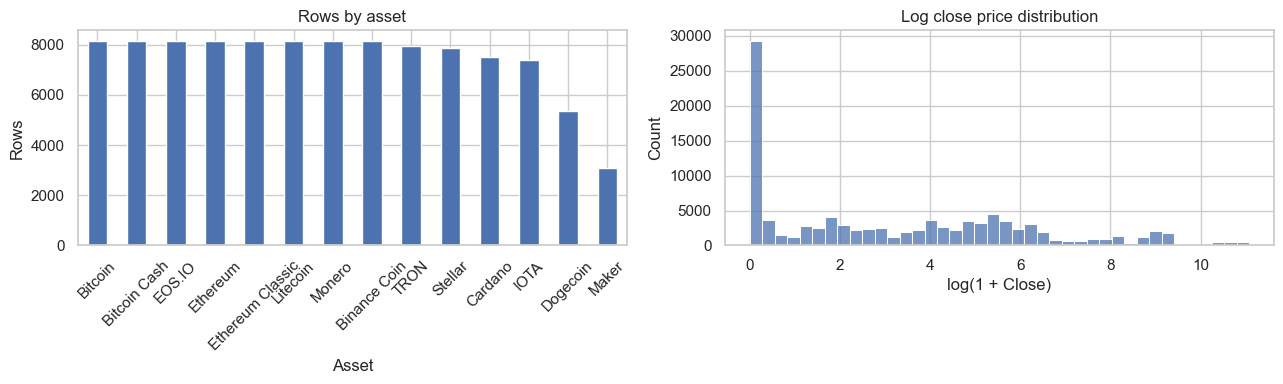

In [4]:
close_for_plot = pd.to_numeric(df_raw["Close"], errors="coerce")
close_for_plot = close_for_plot.replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_raw["Asset_Name"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Rows by asset")
axes[0].set_xlabel("Asset")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=45)

sns.histplot(np.log1p(close_for_plot), bins=40, ax=axes[1])
axes[1].set_title("Log close price distribution")
axes[1].set_xlabel("log(1 + Close)")

plt.tight_layout()
plt.show()


<a id="step-4-clustering-the-assets"></a>

## Step 4: Clustering the assets

We first cluster the assets using only the earlier part of the data. This keeps the clustering step separate from the final test period.
KMeans is the main clustering method because it is simple and was used in the class notebooks. We also compare it with Agglomerative Clustering and DBSCAN.


In [5]:
# The 70% cutoff matches the training period in the chronological split below.
cluster_cutoff = df_raw["timestamp"].quantile(0.70)

df_cluster = df_raw[df_raw["timestamp"] <= cluster_cutoff].sort_values(
    ["Asset_ID", "timestamp"]
).copy()

numeric_cols = df_cluster.select_dtypes(include="number").columns
df_cluster[numeric_cols] = df_cluster[numeric_cols].replace([np.inf, -np.inf], np.nan)
df_cluster = df_cluster.dropna(subset=["Close", "Volume", "VWAP", "Count"])

cluster_group = df_cluster.groupby("Asset_ID", group_keys=False)
df_cluster["return_4h"] = cluster_group["Close"].pct_change()

asset_cluster_features = (
    df_cluster.groupby(["Asset_ID", "Asset_Name"])
    .agg(
        mean_close=("Close", "mean"),
        mean_volume=("Volume", "mean"),
        mean_count=("Count", "mean"),
        mean_return_4h=("return_4h", "mean"),
        volatility_4h=("return_4h", "std"),
    )
    .reset_index()
)

asset_cluster_features["log_mean_close"] = np.log1p(asset_cluster_features["mean_close"])
asset_cluster_features["log_mean_volume"] = np.log1p(asset_cluster_features["mean_volume"])
asset_cluster_features["log_mean_count"] = np.log1p(asset_cluster_features["mean_count"])

cluster_features = [
    "log_mean_close",
    "log_mean_volume",
    "log_mean_count",
    "mean_return_4h",
    "volatility_4h",
]

asset_cluster_features = asset_cluster_features.dropna(subset=cluster_features)

print("Clustering data ends at:", cluster_cutoff)
display(asset_cluster_features[["Asset_Name"] + cluster_features])


Clustering data ends at: 2020-09-13 08:00:00


,Asset_Name,log_mean_close,log_mean_volume,log_mean_count,mean_return_4h,volatility_4h
0,Binance Coin,2.842460,12.899740,9.358667,0.000487,0.023543
1,Bitcoin,8.970966,9.957915,11.899587,0.000086,0.016173
2,Bitcoin Cash,6.185258,10.673766,10.063616,-0.000083,0.024990
3,Cardano,0.078444,17.861483,9.465949,0.000047,0.021719
4,Dogecoin,0.002624,18.419416,7.619103,0.000165,0.018414
5,EOS.IO,1.816057,15.354811,10.561959,0.000143,0.025098
6,Ethereum,5.728074,12.363909,11.266628,0.000098,0.020621
7,Ethereum Classic,2.387977,13.312525,9.515300,-0.000020,0.023738
8,IOTA,0.344924,14.405952,7.997145,-0.000165,0.022147
9,Litecoin,4.367147,12.223703,10.178603,-0.000021,0.021591


,k,inertia,silhouette,davies_bouldin
0,2,36.993,0.585,0.261
1,3,18.413,0.339,0.672
2,4,12.174,0.255,0.790
3,5,9.229,0.237,0.672
4,6,6.582,0.228,0.608


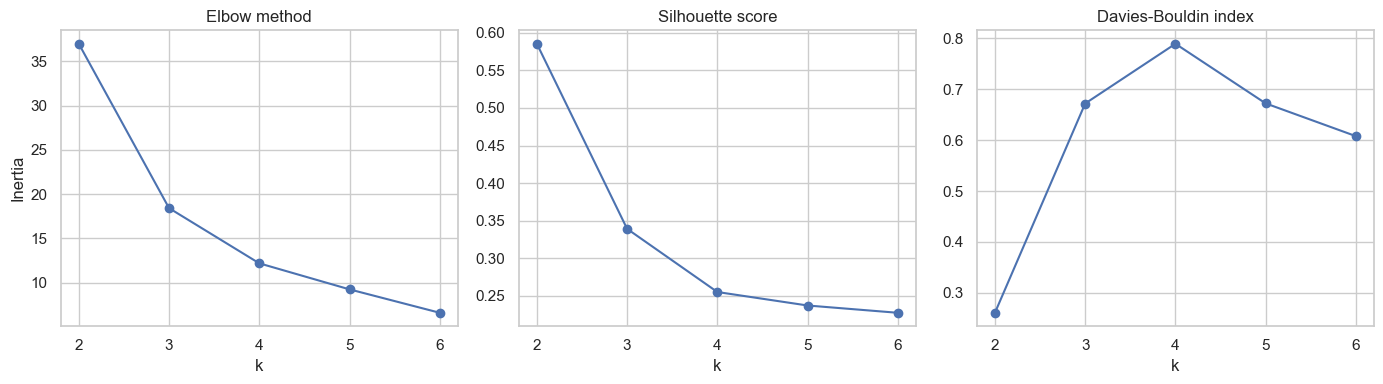

In [6]:
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(asset_cluster_features[cluster_features])

k_values = range(2, 7)
cluster_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = kmeans.fit_predict(X_cluster)
    cluster_scores.append(
        {
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette": silhouette_score(X_cluster, labels),
            "davies_bouldin": davies_bouldin_score(X_cluster, labels),
        }
    )

cluster_scores = pd.DataFrame(cluster_scores)
display(cluster_scores.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(cluster_scores["k"], cluster_scores["inertia"], marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(cluster_scores["k"], cluster_scores["silhouette"], marker="o")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")

axes[2].plot(cluster_scores["k"], cluster_scores["davies_bouldin"], marker="o")
axes[2].set_title("Davies-Bouldin index")
axes[2].set_xlabel("k")

plt.tight_layout()
plt.show()


In [7]:
chosen_k = 3

clustering_models = {
    "KMeans": KMeans(n_clusters=chosen_k, random_state=SEED, n_init=20),
    "Agglomerative": AgglomerativeClustering(n_clusters=chosen_k),
    "DBSCAN": DBSCAN(eps=1.5, min_samples=2),
}

method_rows = []

for name, model in clustering_models.items():
    labels = model.fit_predict(X_cluster)
    valid = labels != -1
    n_clusters = len(set(labels[valid]))
    n_noise = int((labels == -1).sum())

    if n_clusters > 1 and valid.sum() > n_clusters:
        sil = silhouette_score(X_cluster[valid], labels[valid])
        db = davies_bouldin_score(X_cluster[valid], labels[valid])
    else:
        sil = np.nan
        db = np.nan

    asset_cluster_features[name + "_cluster"] = labels
    method_rows.append(
        {
            "method": name,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "silhouette": sil,
            "davies_bouldin": db,
        }
    )

clustering_comparison = pd.DataFrame(method_rows)
asset_cluster_features["asset_cluster"] = asset_cluster_features["KMeans_cluster"]

display(clustering_comparison.round(3))
display(asset_cluster_features[["Asset_ID", "Asset_Name", "asset_cluster"]].sort_values(["asset_cluster", "Asset_Name"]))


,method,clusters,noise_points,silhouette,davies_bouldin
0,KMeans,3,0,0.339,0.672
1,Agglomerative,3,0,0.331,0.641
2,DBSCAN,1,3,NaN,NaN


,Asset_ID,Asset_Name,asset_cluster
10,10,Maker,0
0,0,Binance Coin,1
3,3,Cardano,1
4,4,Dogecoin,1
5,5,EOS.IO,1
7,7,Ethereum Classic,1
8,8,IOTA,1
12,12,Stellar,1
13,13,TRON,1
1,1,Bitcoin,2


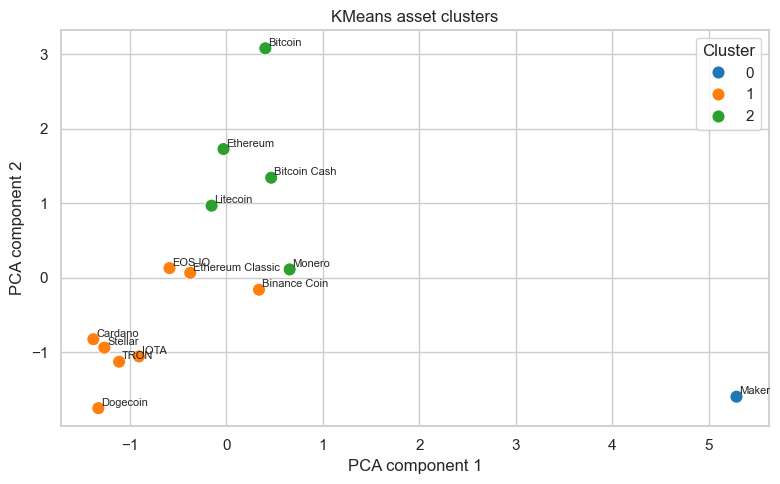

In [8]:
pca = PCA(n_components=2, random_state=SEED)
pca_values = pca.fit_transform(X_cluster)

asset_cluster_features["pca_1"] = pca_values[:, 0]
asset_cluster_features["pca_2"] = pca_values[:, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=asset_cluster_features,
    x="pca_1",
    y="pca_2",
    hue="asset_cluster",
    palette="tab10",
    s=90,
)

for _, row in asset_cluster_features.iterrows():
    plt.text(row["pca_1"] + 0.03, row["pca_2"] + 0.03, row["Asset_Name"], fontsize=8)

plt.title("KMeans asset clusters")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


<a id="step-5-feature-engineering-and-target"></a>

## Step 5: Feature engineering and target

The target is the next 4-hour return:

`future_return = future_price / current Close - 1`

We still output a future price estimate at the end:

`predicted_future_price = current Close * (1 + predicted_future_return)`

This avoids making the model a disguised identity function. `Close`, `VWAP`, `High`, and `Low` are useful for creating return and range features, but they are not used directly in the Ridge model because they are too close to the target price level.

Rows with missing or non-finite values are removed after the target and features are created.


In [9]:
df = df_raw.sort_values(["Asset_ID", "timestamp"]).copy()

numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Open", "High", "Low", "Close", "Volume", "VWAP", "Count"])

df = df.merge(asset_cluster_features[["Asset_ID", "asset_cluster"]], on="Asset_ID", how="left")

asset_group = df.groupby("Asset_ID", group_keys=False)

df["future_price"] = asset_group["Close"].shift(-1)
df["future_return"] = df["future_price"] / df["Close"] - 1

df["candle_return"] = df["Close"] / df["Open"] - 1
df["high_low_range_pct"] = (df["High"] - df["Low"]) / df["Open"]
df["close_vwap_gap_pct"] = (df["Close"] - df["VWAP"]) / df["VWAP"]
df["volume_log"] = np.log1p(df["Volume"])
df["count_log"] = np.log1p(df["Count"])

df["return_4h"] = asset_group["Close"].pct_change(1)
df["return_8h"] = asset_group["Close"].pct_change(2)
df["return_24h"] = asset_group["Close"].pct_change(6)
df["rolling_return_mean_24h"] = asset_group["return_4h"].transform(
    lambda s: s.rolling(6, min_periods=3).mean()
)
df["rolling_volatility_24h"] = asset_group["return_4h"].transform(
    lambda s: s.rolling(6, min_periods=3).std()
)

by_time = df.groupby("timestamp")
df["assets_at_timestamp"] = by_time["return_4h"].transform("count")
df["market_return_4h"] = by_time["return_4h"].transform("mean")
df["other_assets_return_4h"] = (
    df["market_return_4h"] * df["assets_at_timestamp"] - df["return_4h"]
) / (df["assets_at_timestamp"] - 1)

return_table = df.pivot_table(index="timestamp", columns="Asset_Name", values="return_4h")
df["bitcoin_return_4h"] = df["timestamp"].map(return_table["Bitcoin"])
df["ethereum_return_4h"] = df["timestamp"].map(return_table["Ethereum"])

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month

candidate_features = [
    "Count",
    "Volume",
    "volume_log",
    "count_log",
    "candle_return",
    "high_low_range_pct",
    "close_vwap_gap_pct",
    "return_4h",
    "return_8h",
    "return_24h",
    "rolling_return_mean_24h",
    "rolling_volatility_24h",
    "market_return_4h",
    "other_assets_return_4h",
    "bitcoin_return_4h",
    "ethereum_return_4h",
    "hour",
    "day_of_week",
    "month",
]

df_model = df.dropna(subset=candidate_features + ["future_price", "future_return"]).copy()
df_model = df_model.sort_values(["timestamp", "Asset_ID"]).reset_index(drop=True)

print("Model rows:", len(df_model))
print("Candidate features:", len(candidate_features))
print("Rows with non-finite values were removed before this step.")
display(df_model[["timestamp", "Asset_Name", "Close", "future_price", "future_return"] + candidate_features[:6]].head())


Model rows: 104220
Candidate features: 19
Rows with non-finite values were removed before this step.


,timestamp,Asset_Name,Close,future_price,future_return,Count,Volume,volume_log,count_log,candle_return,high_low_range_pct
0,2018-01-02,Binance Coin,8.3986,8.3100,-0.010549,5852.0,245387.240000,12.410597,8.674710,-0.006083,0.037858
1,2018-01-02,Bitcoin,13361.3440,13433.4000,0.005393,101478.0,17001.646278,9.741124,11.527607,-0.004926,0.059505
2,2018-01-02,Bitcoin Cash,2375.5100,2340.9150,-0.014563,25712.0,10974.484639,9.303419,10.154752,0.023536,0.063695
3,2018-01-02,EOS.IO,8.2216,8.1889,-0.003977,6014.0,912278.064362,13.723701,8.702012,0.076112,0.128009
4,2018-01-02,Ethereum,824.3900,850.0625,0.031141,118792.0,308228.416759,12.638600,11.685138,0.090139,0.198936


<a id="step-6-chronological-701020-split"></a>

## Step 6: Chronological 70/10/20 split

The requested train/test/validation proportions are 70% / 20% / 10%. For time-series data, the chronological order is train → validation → final test. Therefore, the table is displayed as 70% train, 10% validation, and 20% test, with the most recent 20% held out for final evaluation.


In [10]:
unique_times = np.array(sorted(df_model["timestamp"].unique()))
n_times = len(unique_times)

train_end_time = unique_times[int(0.70 * n_times) - 1]
validation_end_time = unique_times[int(0.80 * n_times) - 1]

train_df = df_model[df_model["timestamp"] <= train_end_time].copy()
validation_df = df_model[
    (df_model["timestamp"] > train_end_time)
    & (df_model["timestamp"] <= validation_end_time)
].copy()
test_df = df_model[df_model["timestamp"] > validation_end_time].copy()

split_summary = pd.DataFrame(
    {
        "rows": [len(train_df), len(validation_df), len(test_df)],
        "share": [
            len(train_df) / len(df_model),
            len(validation_df) / len(df_model),
            len(test_df) / len(df_model),
        ],
        "start": [
            train_df["timestamp"].min(),
            validation_df["timestamp"].min(),
            test_df["timestamp"].min(),
        ],
        "end": [
            train_df["timestamp"].max(),
            validation_df["timestamp"].max(),
            test_df["timestamp"].max(),
        ],
    },
    index=["train", "validation", "test"],
)

display(split_summary)


,rows,share,start,end
train,69990,0.67156,2018-01-02 00:00:00,2020-08-09 04:00:00
validation,11410,0.10948,2020-08-09 08:00:00,2020-12-23 00:00:00
test,22820,0.21896,2020-12-23 04:00:00,2021-09-20 16:00:00


<a id="step-7-feature-importance-by-cluster"></a>

## Step 7: Feature importance by cluster

We use decision trees with different depths to see which features consistently matter inside each cluster.
This is not the final model. It is a simple feature-selection step before Ridge Regression.


In [11]:
tree_depths = [2, 4, 6]
tree_score_rows = []
tree_importance_rows = []

for cluster_id in sorted(train_df["asset_cluster"].unique()):
    cluster_train = train_df[train_df["asset_cluster"] == cluster_id]
    cluster_val = validation_df[validation_df["asset_cluster"] == cluster_id]

    X_train_cluster = cluster_train[candidate_features]
    y_train_cluster = cluster_train["future_return"]

    for depth in tree_depths:
        tree = DecisionTreeRegressor(
            max_depth=depth,
            min_samples_leaf=100,
            random_state=SEED,
        )
        tree.fit(X_train_cluster, y_train_cluster)

        y_val_pred = tree.predict(cluster_val[candidate_features])

        tree_score_rows.append(
            {
                "cluster": cluster_id,
                "max_depth": depth,
                "validation_MAE_return": mean_absolute_error(cluster_val["future_return"], y_val_pred),
                "validation_RMSE_return": np.sqrt(mean_squared_error(cluster_val["future_return"], y_val_pred)),
                "validation_R2_return": r2_score(cluster_val["future_return"], y_val_pred),
            }
        )

        for feature, importance in zip(candidate_features, tree.feature_importances_):
            tree_importance_rows.append(
                {
                    "cluster": cluster_id,
                    "max_depth": depth,
                    "feature": feature,
                    "importance": importance,
                }
            )

tree_scores = pd.DataFrame(tree_score_rows)
tree_importance = (
    pd.DataFrame(tree_importance_rows)
    .groupby(["cluster", "feature"], as_index=False)["importance"]
    .mean()
    .sort_values(["cluster", "importance"], ascending=[True, False])
)

display(tree_scores.round(6))
display(tree_importance.groupby("cluster").head(8))


,cluster,max_depth,validation_MAE_return,validation_RMSE_return,validation_R2_return
0,0,2,0.015576,0.021319,-0.177613
1,0,4,0.016086,0.021806,-0.232119
2,0,6,0.016086,0.021806,-0.232119
3,1,2,0.013860,0.021295,-0.012845
4,1,4,0.013803,0.021243,-0.007913
5,1,6,0.013862,0.021281,-0.011504
6,2,2,0.011580,0.016724,-0.011273
7,2,4,0.011554,0.016703,-0.008752
8,2,6,0.011559,0.016740,-0.013227


,cluster,feature,importance
8,0,high_low_range_pct,0.541575
17,0,rolling_volatility_24h,0.447130
18,0,volume_log,0.011295
0,0,Count,0.000000
1,0,Volume,0.000000
2,0,bitcoin_return_4h,0.000000
3,0,candle_return,0.000000
4,0,close_vwap_gap_pct,0.000000
34,1,return_8h,0.489127
26,1,ethereum_return_4h,0.272978


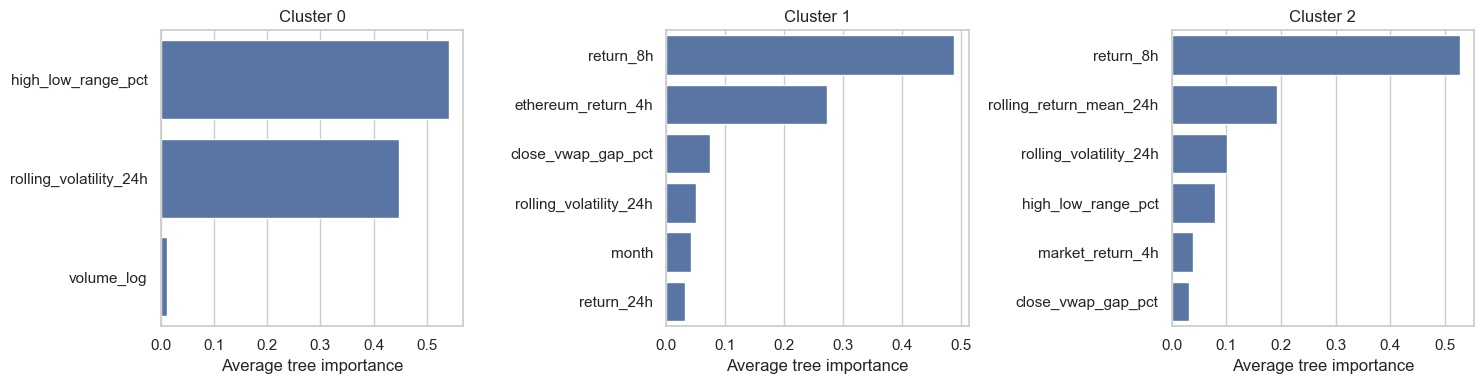

In [12]:
clusters = sorted(tree_importance["cluster"].unique())
fig, axes = plt.subplots(1, len(clusters), figsize=(15, 4))

if len(clusters) == 1:
    axes = [axes]

for ax, cluster_id in zip(axes, clusters):
    top_features = tree_importance[
        (tree_importance["cluster"] == cluster_id)
        & (tree_importance["importance"] > 0.0001)
    ].head(6)

    sns.barplot(data=top_features, y="feature", x="importance", ax=ax)
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Average tree importance")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


<a id="step-8-shap-pdp-ice-and-final-feature-selection"></a>

## Step 8: SHAP, PDP, ICE, and final feature selection

The tree importance tells us which features are useful for predicting the next return. SHAP checks the average contribution of the features.
PDP and ICE plots then show how the strongest selected features affect predictions. Since these are tree models, the ICE curves can look like step functions; that is expected for decision trees.

The table after this section is the actual include / neglect decision for Ridge Regression.


In [13]:
best_depth_by_cluster = (
    tree_scores.sort_values("validation_MAE_return")
    .groupby("cluster")["max_depth"]
    .first()
    .to_dict()
)

tree_models = {}
shap_rows = []

try:
    import shap
    shap_available = True
except Exception as error:
    shap_available = False
    print("SHAP could not be imported. Tree importance will be used instead.")
    print(error)

for cluster_id in sorted(train_df["asset_cluster"].unique()):
    cluster_train = train_df[train_df["asset_cluster"] == cluster_id]
    depth = int(best_depth_by_cluster.get(cluster_id, 4))

    tree = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=100, random_state=SEED)
    tree.fit(cluster_train[candidate_features], cluster_train["future_return"])
    tree_models[cluster_id] = tree

    if shap_available:
        shap_sample = cluster_train.sample(min(300, len(cluster_train)), random_state=SEED)
        X_shap = shap_sample[candidate_features]
        shap_values = shap.TreeExplainer(tree).shap_values(X_shap)

        for feature, value in zip(candidate_features, np.abs(shap_values).mean(axis=0)):
            shap_rows.append(
                {"cluster": cluster_id, "feature": feature, "mean_abs_shap": value}
            )

shap_importance = pd.DataFrame(shap_rows)

if len(shap_importance) > 0:
    top_shap = (
        shap_importance.sort_values(["cluster", "mean_abs_shap"], ascending=[True, False])
        .groupby("cluster")
        .head(6)
    )
    display(top_shap)


,cluster,feature,mean_abs_shap
5,0,high_low_range_pct,0.007728
11,0,rolling_volatility_24h,0.007203
0,0,Count,0.000000
1,0,Volume,0.000000
2,0,volume_log,0.000000
3,0,count_log,0.000000
25,1,close_vwap_gap_pct,0.000320
28,1,return_24h,0.000133
34,1,ethereum_return_4h,0.000115
27,1,return_8h,0.000114


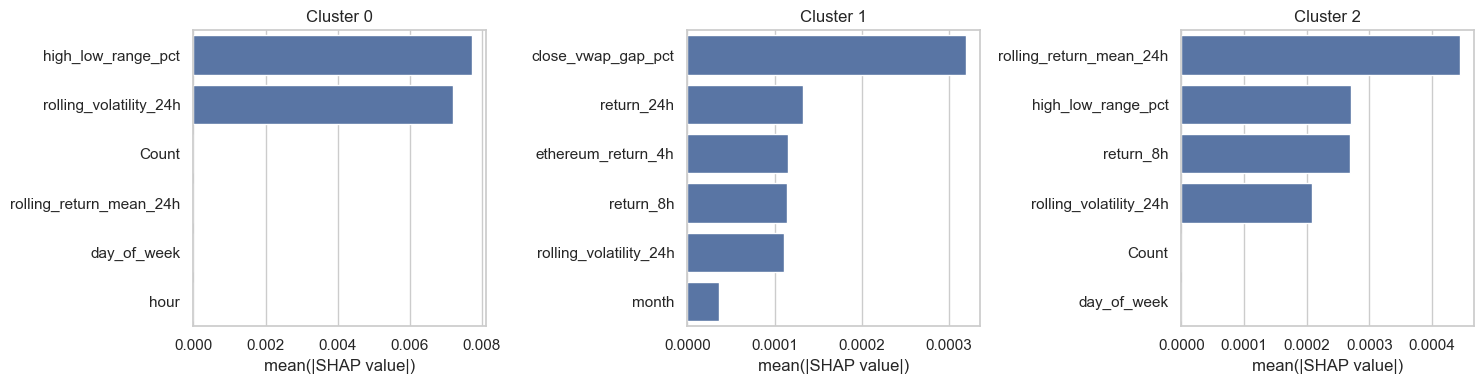

In [14]:
if len(shap_importance) > 0:
    fig, axes = plt.subplots(1, len(clusters), figsize=(15, 4))

    if len(clusters) == 1:
        axes = [axes]

    for ax, cluster_id in zip(axes, clusters):
        top_shap = (
            shap_importance[shap_importance["cluster"] == cluster_id]
            .sort_values("mean_abs_shap", ascending=False)
            .head(6)
        )
        sns.barplot(data=top_shap, y="feature", x="mean_abs_shap", ax=ax)
        ax.set_title(f"Cluster {cluster_id}")
        ax.set_xlabel("mean(|SHAP value|)")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.show()


In [15]:
top_n_features = 6

feature_decision = tree_importance.merge(
    shap_importance,
    on=["cluster", "feature"],
    how="left",
)
feature_decision["mean_abs_shap"] = feature_decision["mean_abs_shap"].fillna(0)

feature_decision["tree_rank"] = feature_decision.groupby("cluster")["importance"].rank(
    method="first", ascending=False
)
feature_decision["shap_rank"] = feature_decision.groupby("cluster")["mean_abs_shap"].rank(
    method="first", ascending=False
)
feature_decision["selection_rank"] = feature_decision[["tree_rank", "shap_rank"]].mean(axis=1)
feature_decision["decision"] = "do not include in Ridge"

ridge_features_by_cluster = {}
ridge_neglected_by_cluster = {}

for cluster_id in sorted(feature_decision["cluster"].unique()):
    cluster_table = feature_decision[feature_decision["cluster"] == cluster_id].sort_values("selection_rank")

    selected = cluster_table[cluster_table["importance"] > 0.0001].head(top_n_features)
    if len(selected) == 0:
        selected = cluster_table.head(top_n_features)

    selected_features = selected["feature"].tolist()
    ridge_features_by_cluster[cluster_id] = selected_features

    include = (
        (feature_decision["cluster"] == cluster_id)
        & (feature_decision["feature"].isin(selected_features))
    )
    feature_decision.loc[include, "decision"] = "include in Ridge"

    ridge_neglected_by_cluster[cluster_id] = feature_decision[
        (feature_decision["cluster"] == cluster_id)
        & (~feature_decision["feature"].isin(selected_features))
    ]["feature"].tolist()

feature_decision_view = feature_decision[
    ["cluster", "feature", "importance", "mean_abs_shap", "decision"]
].sort_values(["cluster", "decision", "importance"], ascending=[True, True, False])

ridge_feature_summary = pd.DataFrame(
    [
        {
            "cluster": cluster_id,
            "include_in_Ridge": ridge_features_by_cluster[cluster_id],
            "neglect": ridge_neglected_by_cluster[cluster_id],
        }
        for cluster_id in sorted(ridge_features_by_cluster)
    ]
)

display(feature_decision_view)
display(ridge_feature_summary)


,cluster,feature,importance,mean_abs_shap,decision
3,0,Count,0.000000,0.000000,do not include in Ridge
4,0,Volume,0.000000,0.000000,do not include in Ridge
5,0,bitcoin_return_4h,0.000000,0.000000,do not include in Ridge
6,0,candle_return,0.000000,0.000000,do not include in Ridge
7,0,close_vwap_gap_pct,0.000000,0.000000,do not include in Ridge
8,0,count_log,0.000000,0.000000,do not include in Ridge
9,0,day_of_week,0.000000,0.000000,do not include in Ridge
10,0,ethereum_return_4h,0.000000,0.000000,do not include in Ridge
11,0,hour,0.000000,0.000000,do not include in Ridge
12,0,market_return_4h,0.000000,0.000000,do not include in Ridge


,cluster,include_in_Ridge,neglect
0,0,"[high_low_range_pct, rolling_volatility_24h, volume_log]","[Count, Volume, bitcoin_return_4h, candle_return, close_vwap_gap_pct, count_log, day_of_week, ethereum_return_4h, ho..."
1,1,"[close_vwap_gap_pct, return_8h, ethereum_return_4h, return_24h, rolling_volatility_24h, month]","[bitcoin_return_4h, hour, Count, Volume, candle_return, count_log, day_of_week, high_low_range_pct, market_return_4h..."
2,2,"[rolling_return_mean_24h, return_8h, high_low_range_pct, rolling_volatility_24h, market_return_4h, close_vwap_gap_pct]","[ethereum_return_4h, Count, Volume, bitcoin_return_4h, candle_return, count_log, day_of_week, hour, month, other_ass..."


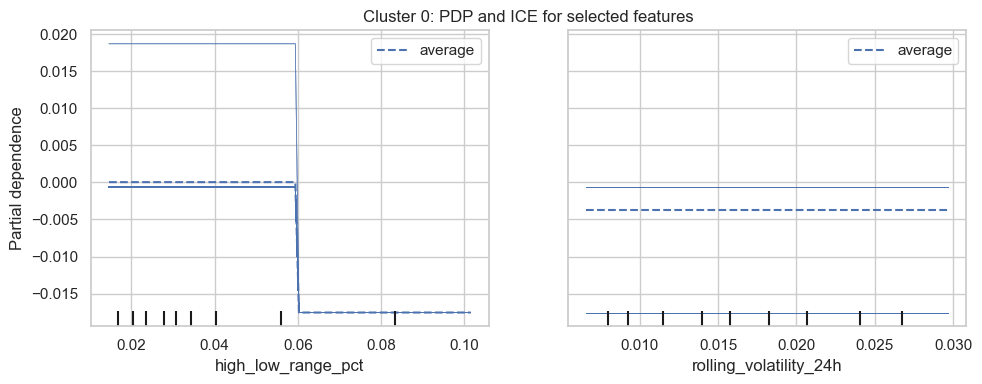

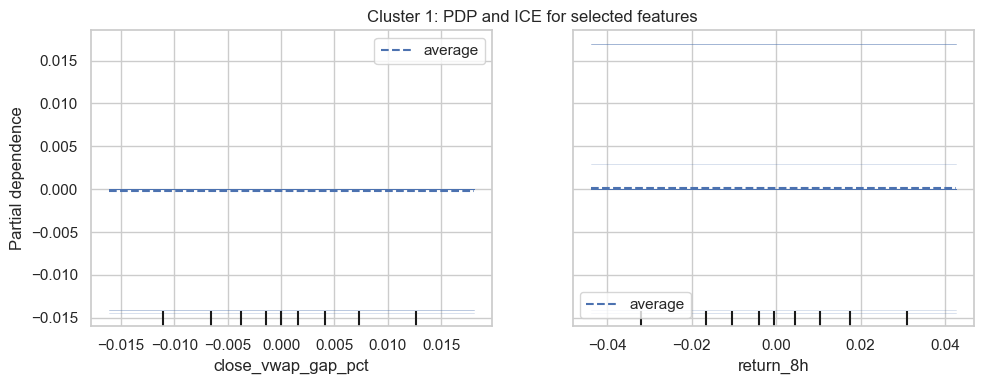

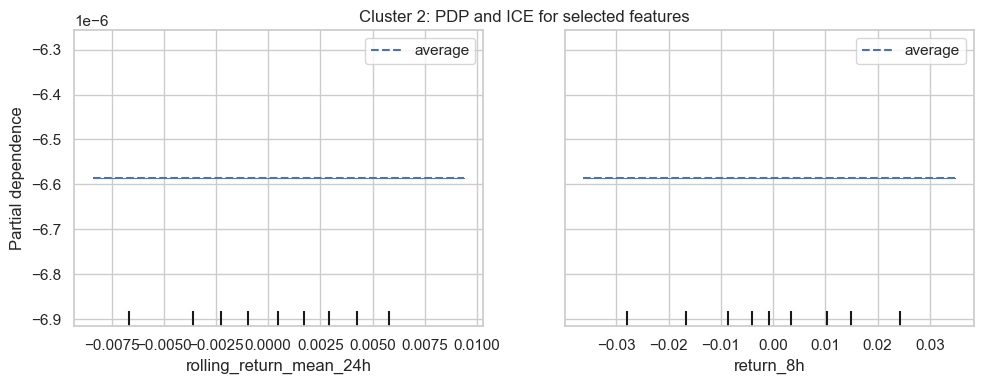

In [16]:
for cluster_id, tree in tree_models.items():
    cluster_val = validation_df[validation_df["asset_cluster"] == cluster_id]
    if len(cluster_val) == 0:
        continue

    features_to_plot = ridge_features_by_cluster[cluster_id][:2]
    X_plot = cluster_val.sample(min(200, len(cluster_val)), random_state=SEED)[candidate_features]

    fig, ax = plt.subplots(figsize=(10, 4))
    PartialDependenceDisplay.from_estimator(
        tree,
        X_plot,
        features=features_to_plot,
        kind="both",
        ax=ax,
    )
    ax.set_title(f"Cluster {cluster_id}: PDP and ICE for selected features")
    plt.tight_layout()
    plt.show()


In [17]:
for cluster_id in sorted(ridge_features_by_cluster):
    print(f"Cluster {cluster_id}")
    print("Include:", ", ".join(ridge_features_by_cluster[cluster_id]))
    print("Neglect:", ", ".join(ridge_neglected_by_cluster[cluster_id]))
    print()


Cluster 0
Include: high_low_range_pct, rolling_volatility_24h, volume_log
Neglect: Count, Volume, bitcoin_return_4h, candle_return, close_vwap_gap_pct, count_log, day_of_week, ethereum_return_4h, hour, market_return_4h, month, other_assets_return_4h, return_24h, return_4h, return_8h, rolling_return_mean_24h

Cluster 1
Include: close_vwap_gap_pct, return_8h, ethereum_return_4h, return_24h, rolling_volatility_24h, month
Neglect: bitcoin_return_4h, hour, Count, Volume, candle_return, count_log, day_of_week, high_low_range_pct, market_return_4h, other_assets_return_4h, return_4h, rolling_return_mean_24h, volume_log

Cluster 2
Include: rolling_return_mean_24h, return_8h, high_low_range_pct, rolling_volatility_24h, market_return_4h, close_vwap_gap_pct
Neglect: ethereum_return_4h, Count, Volume, bitcoin_return_4h, candle_return, count_log, day_of_week, hour, month, other_assets_return_4h, return_24h, return_4h, volume_log



<a id="step-9-asset-specific-ridge-regression-and-baselines"></a>

## Step 9: Asset-specific Ridge Regression and baselines

We now train one Ridge Regression model for each asset. Each asset uses only the features selected for its cluster.

The Ridge model predicts next-bar return and then converts this into a future price estimate. We compare it against two simple baselines:

- **Persistence:** predicted future price equals the current `Close`.
- **Rolling return baseline:** predicted future return equals the recent 24-hour average return.

This comparison is important because a price-level model can look excellent even if it only copies the current price.


In [18]:
def evaluate_prediction(y_true_price, y_pred_price, y_true_return, y_pred_return):
    return {
        "price_MAE": mean_absolute_error(y_true_price, y_pred_price),
        "price_RMSE": np.sqrt(mean_squared_error(y_true_price, y_pred_price)),
        "price_R2": r2_score(y_true_price, y_pred_price),
        "price_MAPE_percent": mean_absolute_percentage_error(y_true_price, y_pred_price) * 100,
        "return_MAE": mean_absolute_error(y_true_return, y_pred_return),
        "return_RMSE": np.sqrt(mean_squared_error(y_true_return, y_pred_return)),
        "return_R2": r2_score(y_true_return, y_pred_return),
    }


ridge_alpha_values = [0.1, 1.0, 10.0, 100.0]

asset_models = {}
model_rows = []
coefficient_rows = []
prediction_frames = []

for asset_name in sorted(train_df["Asset_Name"].unique()):
    asset_train = train_df[train_df["Asset_Name"] == asset_name]
    asset_val = validation_df[validation_df["Asset_Name"] == asset_name]
    asset_test = test_df[test_df["Asset_Name"] == asset_name]

    if len(asset_train) < 50 or len(asset_val) == 0 or len(asset_test) == 0:
        continue

    cluster_id = int(asset_train["asset_cluster"].iloc[0])
    features = ridge_features_by_cluster[cluster_id]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(asset_train[features])
    X_val = scaler.transform(asset_val[features])

    validation_mae = []
    for alpha in ridge_alpha_values:
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_train, asset_train["future_return"])
        pred_val_return = ridge.predict(X_val)
        validation_mae.append(mean_absolute_error(asset_val["future_return"], pred_val_return))

    best_alpha = ridge_alpha_values[int(np.argmin(validation_mae))]

    train_val = pd.concat([asset_train, asset_val])
    scaler = StandardScaler()
    X_train_val = scaler.fit_transform(train_val[features])
    X_test = scaler.transform(asset_test[features])

    ridge = Ridge(alpha=best_alpha)
    ridge.fit(X_train_val, train_val["future_return"])

    ridge_return = ridge.predict(X_test)
    persistence_return = np.zeros(len(asset_test))
    rolling_return = asset_test["rolling_return_mean_24h"].to_numpy()

    comparison = {
        "Ridge": ridge_return,
        "Persistence": persistence_return,
        "Rolling_return_24h": rolling_return,
    }

    for model_name, return_prediction in comparison.items():
        price_prediction = asset_test["Close"] * (1 + return_prediction)
        row = {
            "Asset_Name": asset_name,
            "cluster": cluster_id,
            "model": model_name,
            "best_alpha": best_alpha if model_name == "Ridge" else np.nan,
            "features": features if model_name == "Ridge" else [],
        }
        row.update(
            evaluate_prediction(
                asset_test["future_price"],
                price_prediction,
                asset_test["future_return"],
                return_prediction,
            )
        )
        model_rows.append(row)

    for feature, coefficient in zip(features, ridge.coef_):
        coefficient_rows.append(
            {
                "Asset_Name": asset_name,
                "cluster": cluster_id,
                "best_alpha": best_alpha,
                "intercept": ridge.intercept_,
                "feature": feature,
                "coefficient": coefficient,
            }
        )

    pred = asset_test[["timestamp", "Asset_Name", "Close", "future_price", "future_return"]].copy()
    pred["predicted_future_return"] = ridge_return
    pred["predicted_future_price"] = pred["Close"] * (1 + ridge_return)
    pred["persistence_future_price"] = pred["Close"] * (1 + persistence_return)
    pred["rolling_return_future_price"] = pred["Close"] * (1 + rolling_return)
    pred["absolute_error"] = (pred["future_price"] - pred["predicted_future_price"]).abs()
    prediction_frames.append(pred)

    asset_models[asset_name] = {
        "model": ridge,
        "scaler": scaler,
        "features": features,
        "cluster": cluster_id,
    }

model_results = pd.DataFrame(model_rows)
ridge_results = model_results[model_results["model"] == "Ridge"].sort_values("price_MAPE_percent")
baseline_comparison = (
    model_results.pivot_table(
        index="Asset_Name",
        columns="model",
        values="price_MAPE_percent",
        aggfunc="first",
    )
    .reset_index()
)
baseline_comparison["Ridge_minus_Persistence_MAPE"] = (
    baseline_comparison["Ridge"] - baseline_comparison["Persistence"]
)

ridge_coefficients = pd.DataFrame(coefficient_rows).sort_values(["Asset_Name", "feature"])
predictions = pd.concat(prediction_frames, ignore_index=True)

result_columns = [
    "Asset_Name",
    "cluster",
    "model",
    "best_alpha",
    "price_MAE",
    "price_RMSE",
    "price_MAPE_percent",
    "return_MAE",
    "return_RMSE",
    "return_R2",
]

display(model_results[result_columns].sort_values(["Asset_Name", "model"]).round(6))
display(baseline_comparison.round(4))
display(ridge_coefficients.round(6))


,Asset_Name,cluster,model,best_alpha,price_MAE,price_RMSE,price_MAPE_percent,return_MAE,return_RMSE,return_R2
1,Binance Coin,1,Persistence,NaN,6.226015,10.151908,2.023502,0.020287,0.030415,-0.004003
0,Binance Coin,1,Ridge,100.0,6.214212,10.162952,2.018056,0.020200,0.030342,0.000822
2,Binance Coin,1,Rolling_return_24h,NaN,6.990430,11.174519,2.250266,0.022510,0.032827,-0.169528
4,Bitcoin,2,Persistence,NaN,594.878455,847.484176,1.395698,0.013953,0.019967,-0.000812
3,Bitcoin,2,Ridge,100.0,595.462605,848.938846,1.397665,0.013968,0.020001,-0.004206
5,Bitcoin,2,Rolling_return_24h,NaN,674.134073,926.839987,1.578606,0.015789,0.021857,-0.199229
7,Bitcoin Cash,2,Persistence,NaN,13.239128,22.481406,1.999007,0.019948,0.029027,-0.000706
6,Bitcoin Cash,2,Ridge,100.0,13.323754,22.470989,2.012366,0.020080,0.029133,-0.007989
8,Bitcoin Cash,2,Rolling_return_24h,NaN,14.728461,24.842446,2.230905,0.022265,0.031881,-0.207128
10,Cardano,1,Persistence,NaN,0.027702,0.043468,2.177204,0.021886,0.031261,-0.004488


model,Asset_Name,Persistence,Ridge,Rolling_return_24h,Ridge_minus_Persistence_MAPE
0,Binance Coin,2.0235,2.0181,2.2503,-0.0054
1,Bitcoin,1.3957,1.3977,1.5786,0.0020
2,Bitcoin Cash,1.9990,2.0124,2.2309,0.0134
3,Cardano,2.1772,2.1626,2.4206,-0.0146
4,Dogecoin,2.8169,2.8343,3.1972,0.0174
5,EOS.IO,2.2317,2.2350,2.5083,0.0033
6,Ethereum,1.8211,1.8039,2.0261,-0.0172
7,Ethereum Classic,2.3717,2.3521,2.6037,-0.0197
8,IOTA,2.5842,2.5676,2.8655,-0.0166
9,Litecoin,2.0064,2.0020,2.2784,-0.0044


,Asset_Name,cluster,best_alpha,intercept,feature,coefficient
0,Binance Coin,1,100.0,0.000474,close_vwap_gap_pct,-0.001589
2,Binance Coin,1,100.0,0.000474,ethereum_return_4h,0.001092
5,Binance Coin,1,100.0,0.000474,month,-0.000375
3,Binance Coin,1,100.0,0.000474,return_24h,0.000545
1,Binance Coin,1,100.0,0.000474,return_8h,-0.000526
4,Binance Coin,1,100.0,0.000474,rolling_volatility_24h,0.001207
11,Bitcoin,2,100.0,0.000212,close_vwap_gap_pct,-0.001382
8,Bitcoin,2,100.0,0.000212,high_low_range_pct,0.000220
10,Bitcoin,2,100.0,0.000212,market_return_4h,0.001374
7,Bitcoin,2,100.0,0.000212,return_8h,-0.000533


<a id="step-10-performance-analysis"></a>

## Step 10: Performance analysis

The table and plots below are the final test-set evaluation. MAE and RMSE are in price units, while MAPE makes the errors more comparable across high-price and low-price assets.

Price-level R² is still reported because the output is a future price estimate, but it should not be over-interpreted. The more important checks are the return errors and whether Ridge beats the persistence baseline.


In [19]:
print("Average Ridge test MAPE:", round(ridge_results["price_MAPE_percent"].mean(), 2), "%")
print("Median Ridge test MAPE:", round(ridge_results["price_MAPE_percent"].median(), 2), "%")
print("Average Ridge return R2:", round(ridge_results["return_R2"].mean(), 4))
print("Best Ridge asset by MAPE:", ridge_results.iloc[0]["Asset_Name"])
print("Worst Ridge asset by MAPE:", ridge_results.iloc[-1]["Asset_Name"])

better_than_persistence = (baseline_comparison["Ridge_minus_Persistence_MAPE"] < 0).sum()
print("Assets where Ridge beats persistence by MAPE:", better_than_persistence, "out of", len(baseline_comparison))

display(
    ridge_results[
        [
            "Asset_Name",
            "cluster",
            "best_alpha",
            "price_MAE",
            "price_RMSE",
            "price_MAPE_percent",
            "return_MAE",
            "return_RMSE",
            "return_R2",
        ]
    ].round(6)
)
display(baseline_comparison.sort_values("Ridge_minus_Persistence_MAPE").round(4))


Average Ridge test MAPE: 2.14 %
Median Ridge test MAPE: 2.09 %
Average Ridge return R2: -0.0041
Best Ridge asset by MAPE: Bitcoin
Worst Ridge asset by MAPE: Dogecoin
Assets where Ridge beats persistence by MAPE: 8 out of 14


,Asset_Name,cluster,best_alpha,price_MAE,price_RMSE,price_MAPE_percent,return_MAE,return_RMSE,return_R2
3,Bitcoin,2,100.0,595.462605,848.938846,1.397665,0.013968,0.020001,-0.004206
18,Ethereum,2,100.0,39.446836,57.816624,1.803921,0.018028,0.025224,0.005118
33,Monero,2,100.0,4.921717,7.653474,1.956963,0.019487,0.028504,0.009049
27,Litecoin,2,100.0,3.816350,5.824951,2.002021,0.019927,0.028017,0.003719
39,TRON,1,100.0,0.001537,0.002544,2.005871,0.020026,0.029071,-0.005982
6,Bitcoin Cash,2,100.0,13.323754,22.470989,2.012366,0.020080,0.029133,-0.007989
0,Binance Coin,1,100.0,6.214212,10.162952,2.018056,0.020200,0.030342,0.000822
9,Cardano,1,100.0,0.027480,0.043247,2.162634,0.021721,0.031095,0.006146
15,EOS.IO,1,100.0,0.118256,0.223070,2.234955,0.022328,0.033723,-0.003683
36,Stellar,1,100.0,0.008618,0.013336,2.267536,0.022682,0.033145,-0.002150


model,Asset_Name,Persistence,Ridge,Rolling_return_24h,Ridge_minus_Persistence_MAPE
7,Ethereum Classic,2.3717,2.3521,2.6037,-0.0197
6,Ethereum,1.8211,1.8039,2.0261,-0.0172
8,IOTA,2.5842,2.5676,2.8655,-0.0166
3,Cardano,2.1772,2.1626,2.4206,-0.0146
13,TRON,2.0127,2.0059,2.2581,-0.0068
0,Binance Coin,2.0235,2.0181,2.2503,-0.0054
9,Litecoin,2.0064,2.0020,2.2784,-0.0044
11,Monero,1.9602,1.9570,2.1819,-0.0033
1,Bitcoin,1.3957,1.3977,1.5786,0.0020
5,EOS.IO,2.2317,2.2350,2.5083,0.0033


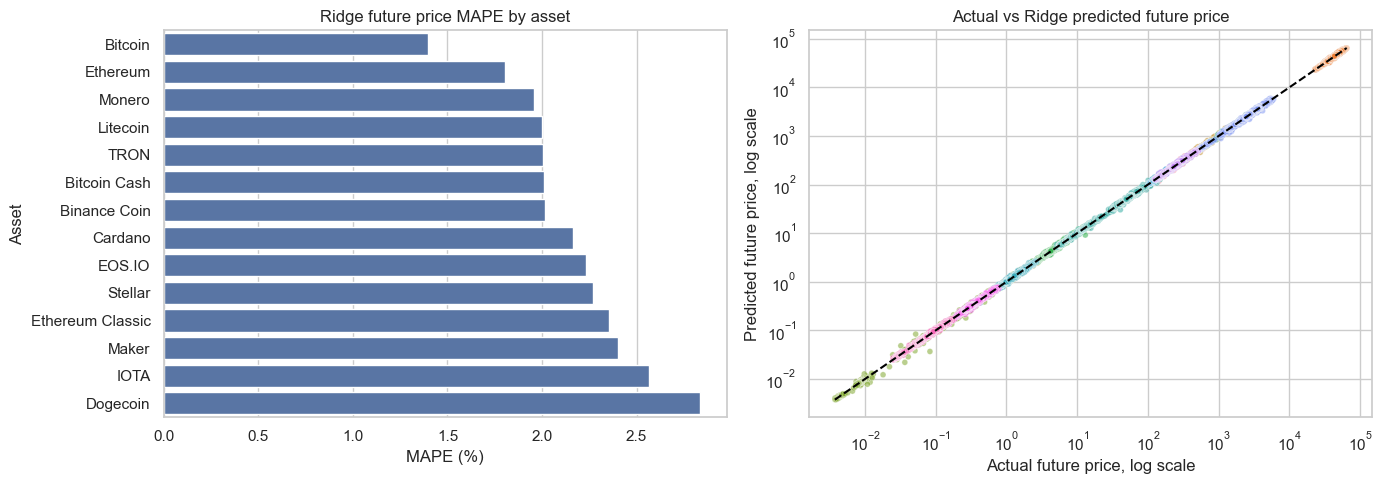

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=ridge_results,
    y="Asset_Name",
    x="price_MAPE_percent",
    ax=axes[0],
    orient="h",
)
axes[0].set_title("Ridge future price MAPE by asset")
axes[0].set_xlabel("MAPE (%)")
axes[0].set_ylabel("Asset")

sns.scatterplot(
    data=predictions,
    x="future_price",
    y="predicted_future_price",
    hue="Asset_Name",
    alpha=0.55,
    s=18,
    ax=axes[1],
    legend=False,
)

min_price = min(predictions["future_price"].min(), predictions["predicted_future_price"].min())
max_price = max(predictions["future_price"].max(), predictions["predicted_future_price"].max())
axes[1].plot([min_price, max_price], [min_price, max_price], color="black", linestyle="--")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Actual vs Ridge predicted future price")
axes[1].set_xlabel("Actual future price, log scale")
axes[1].set_ylabel("Predicted future price, log scale")

plt.tight_layout()
plt.show()


In [21]:
example_asset = ridge_results.iloc[0]["Asset_Name"]
example_features = asset_models[example_asset]["features"]

example_row = test_df[test_df["Asset_Name"] == example_asset].iloc[-1]
example_parameters = example_row[example_features].to_dict()

def predict_future_price_for_asset(asset_name, current_close, parameters):
    model_info = asset_models[asset_name]
    row = pd.DataFrame([parameters])
    row_scaled = model_info["scaler"].transform(row[model_info["features"]])
    predicted_return = model_info["model"].predict(row_scaled)[0]
    predicted_price = current_close * (1 + predicted_return)
    return predicted_return, predicted_price

example_return, example_price = predict_future_price_for_asset(
    example_asset,
    example_row["Close"],
    example_parameters,
)

print("Example asset:", example_asset)
print("Features used:", example_features)
print("Current Close:", round(example_row["Close"], 6))
print("Predicted future return:", round(example_return, 6))
print("Predicted future price:", round(example_price, 6))
print("Realized future price:", round(example_row["future_price"], 6))
print("Absolute error:", round(abs(example_row["future_price"] - example_price), 6))
display(pd.DataFrame([example_parameters]))


Example asset: Bitcoin
Features used: ['rolling_return_mean_24h', 'return_8h', 'high_low_range_pct', 'rolling_volatility_24h', 'market_return_4h', 'close_vwap_gap_pct']
Current Close: 43861.215714
Predicted future return: -0.002049
Predicted future price: 43771.362257
Realized future price: 43017.277143
Absolute error: 754.085114


,rolling_return_mean_24h,return_8h,high_low_range_pct,rolling_volatility_24h,market_return_4h,close_vwap_gap_pct
0,-0.012675,0.00296,0.031422,0.015341,-0.011651,0.005374


<a id="step-11-limitations"></a>

## Step 11: Limitations

- The data is historical and only includes the assets available in this dataset, so survivorship bias may still exist.
- The test period is a different market regime from parts of the training period. This is visible when some assets have much worse test error than train/validation error.
- The model ignores transaction costs, bid-ask spreads, slippage, latency, and market impact. These would matter for a real trading or market-making system.
- The prediction horizon is 4 hours. A real market maker usually manages inventory and quotes on much shorter horizons.
- Even after switching to a return target, financial returns are noisy. The baseline comparison is therefore more important than the headline R².


<a id="step-12-conclusion"></a>

## Step 12: Conclusion

The final model stays intentionally simple. The process is:

1. Cluster assets with KMeans and compare the clustering with alternative methods.
2. Predict next 4-hour return instead of absolute price level, then convert the prediction into a future price estimate.
3. Analyze feature importance inside each cluster with decision trees, SHAP, PDP, and ICE.
4. Explicitly decide which features to include and which features to neglect.
5. Train one Ridge Regression model per asset using only the selected features.
6. Compare Ridge against simple persistence and rolling-return baselines on the final test period.

The clustering step is useful as a diagnostic. If some clusters select similar features, that is also a result: under this simple feature set, the assets may behave more similarly than expected.

The main result is not that crypto prices can be predicted perfectly. The main result is a transparent machine learning process for selecting useful features and checking whether a simple Ridge model adds value beyond naive baselines.
